# Dichromatic Pattern and CSL Visualisation

This notebook visualises the coincident site lattice (CSL) and dichromatic pattern for a chosen grain boundary. It shows:

- Atoms from both grains projected onto the GB plane
- The CSL lattice (overlapping sites from both grains)
- DSC vectors (displacement shift complete lattice) -- the smallest translation vectors that preserve CSL symmetry

**Reference**: Sutton & Balluffi, *Interfaces in Crystalline Materials*, Clarendon Press, 1996.

In [1]:
import numpy as np
from numpy import dot, degrees, array
from numpy.linalg import norm
from math import atan2, asin
import pandas as pd
import matplotlib.pyplot as plt

import gb_code.csl_generator as csl

## 1. Choose a rotation axis and Sigma value

In [2]:
axis = np.array([1, 1, 1])
basis = 'fcc'

csl.print_list(axis, 50)

Sigma:     1  Theta:   0.00 
Sigma:     3  Theta:  60.00 
Sigma:     7  Theta:  38.21 
Sigma:    13  Theta:  27.80 
Sigma:    19  Theta:  46.83 
Sigma:    21  Theta:  21.79 
Sigma:    31  Theta:  17.90 
Sigma:    37  Theta:  50.57 
Sigma:    39  Theta:  32.20 
Sigma:    43  Theta:  15.18 
Sigma:    49  Theta:  43.57 


In [3]:
sigma = 7

theta, m, n = csl.get_theta_m_n_list(axis, sigma)[0]
R = csl.rot(axis, theta)
M1, M2 = csl.Create_minimal_cell_Method_1(sigma, axis, R)

print(f'Sigma {sigma}, Angle: {degrees(theta):.2f} deg')
print(f'Minimal CSL cells:\n{M1}\n{M2}')

Sigma 7, Angle: 38.21 deg
Minimal CSL cells:
[[ 1  0  1]
 [ 0 -2  1]
 [-2  1  1]]
[[ 0  1  1]
 [ 1 -2  1]
 [-2  0  1]]


## 2. Generate GB plane list and select a plane

In [4]:
lim = 5
V1, V2, M, Gb = csl.Create_Possible_GB_Plane_List(axis, m, n, lim)

df = pd.DataFrame({'GB1': list(V1), 'GB2': list(V2), 'Type': Gb})
df.head(10)

,GB1,GB2,Type
0,"[-1, -1, -1]","[-1, -1, -1]",Twist
1,"[0, -2, 1]","[1, -2, 0]",Mixed
2,"[0, 2, -1]","[-1, 2, 0]",Mixed
3,"[1, 0, -2]","[0, 1, -2]",Mixed
4,"[-1, 0, 2]","[0, -1, 2]",Mixed
5,"[1, 1, 1]","[1, 1, 1]",Twist
6,"[-1, -3, 0]","[0, -3, -1]",Mixed
7,"[0, -1, -3]","[-1, 0, -3]",Mixed
8,"[-1, -2, 3]","[1, -3, 2]",Symmetric Tilt
9,"[-1, 2, 1]","[-1, 1, 2]",Mixed


In [5]:
# Select the twist boundary plane [1,1,1]
v1 = np.array([1, 1, 1])

O1, O2, num_atoms = csl.Find_Orthogonal_cell(basis, axis, m, n, v1)
print(f'Orthogonal cell has {num_atoms} atoms')

Orthogonal cell has 84 atoms


## 3. Dichromatic pattern plotter

The function below projects atoms from both grains and the CSL lattice onto a chosen GB plane, viewed along the plane normal.

- **Black dots**: Grain 1 atoms on the plane
- **Green dots**: Grain 2 atoms (rotated) on the plane
- **Yellow dots**: CSL sites (coincident positions)

In [6]:
def plot_dichromatic_pattern(v1, R, basis, M1, sigma, lim=6,
                              plane_thickness=0.1):
    """
    Plot the dichromatic pattern on plane v1.

    Shows atoms from both grains and CSL coincident sites,
    viewed along the plane normal.
    """
    v = dot(R, v1)

    # Generate a cubic grid of lattice points
    coords = np.arange(-lim, lim)
    grid = np.stack(np.meshgrid(coords, coords, coords)).T
    indices = grid.reshape(-1, 3)

    # Build lattice with basis atoms
    base = csl.Basis(str(basis))
    atoms1 = np.vstack([indices[i] + base[j]
                        for i in range(len(indices))
                        for j in range(len(base))])

    # Rotated grain
    atoms2 = dot(R, atoms1.T).T

    # CSL lattice
    csl_cell = np.round(dot(R, csl.CSL_vec(basis, M1)), 7)
    csl_pts = np.array([
        indices[i, 0] * csl_cell[:, 0] +
        indices[i, 1] * csl_cell[:, 1] +
        indices[i, 2] * csl_cell[:, 2]
        for i in range(len(indices))
    ])

    # Filter atoms near the plane
    on_plane1 = atoms1[np.abs(dot(atoms1, v)) <= plane_thickness]
    on_plane2 = atoms2[np.abs(dot(atoms2, v)) <= plane_thickness]
    on_plane_csl = csl_pts[np.abs(dot(csl_pts, v)) <= plane_thickness]

    # Plot
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(*on_plane1.T, s=5, c='black', label='Grain 1')
    ax.scatter(*on_plane2.T, s=50, c='green', alpha=0.2, label='Grain 2')
    ax.scatter(*on_plane_csl.T, s=100, c='gold', alpha=0.3, label='CSL')

    ax.set_proj_type('ortho')
    ax.axis('scaled')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.grid(False)

    # View along plane normal
    az = degrees(atan2(v[1], v[0]))
    el = degrees(asin(v[2] / norm(v)))
    ax.view_init(azim=az, elev=el)

    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.legend()
    return ax

## 4. Twist boundary with DSC vectors

DSC vectors are the smallest translation vectors that preserve CSL symmetry. They are therefore possible Burgers vectors of grain boundary dislocations.

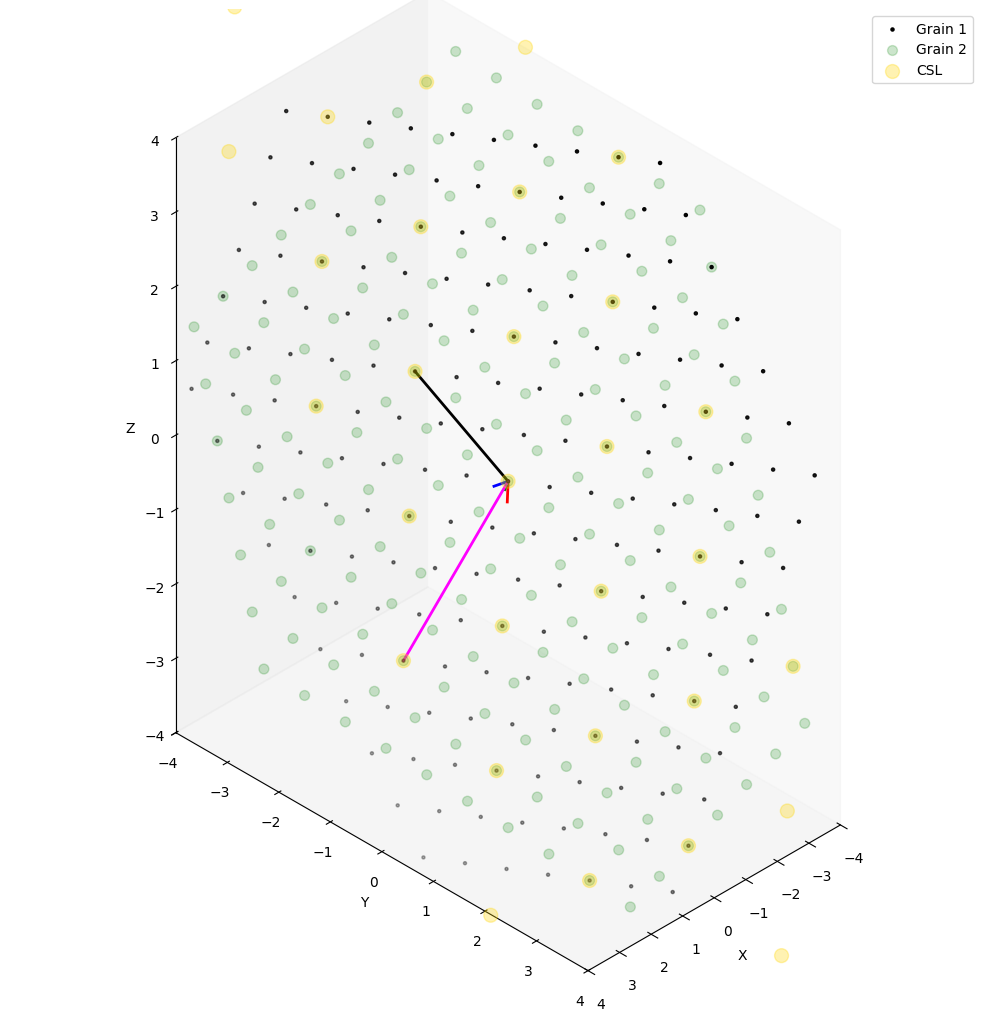

In [7]:
ax = plot_dichromatic_pattern(v1, R, basis, M1, sigma, lim=4)

def plot_line(ax, vec, origin=(0, 0, 0), length=1, color='k', lw=2):
    """Draw a vector as a line in 3D."""
    o = np.array(origin)
    ax.plot([o[0], length * vec[0] + o[0]],
            [o[1], length * vec[1] + o[1]],
            [o[2], length * vec[2] + o[2]], color=color, lw=lw)

# DSC vectors
dsc_cell = np.round(dot(R, 1 / sigma * csl.DSC_vec(basis, sigma, M1)), 7)
plot_line(ax, dsc_cell[:, 0], color='red')
plot_line(ax, dsc_cell[:, 1], color='blue')
plot_line(ax, dsc_cell[:, 2], color='green')

# Orthogonal CSL vectors on the plane
plot_line(ax, O2[:, 1], color='black')
plot_line(ax, O2[:, 2], color='magenta')

plt.tight_layout()
plt.show()

## 5. Advanced: faceted grain boundaries

A high-index boundary plane can be decomposed into two lower-energy facets, provided all three planes belong to the CSL. This technique was used in [Hadian et al., Phys. Rev. Materials 2, 043601 (2018)](https://journals.aps.org/prmaterials/abstract/10.1103/PhysRevMaterials.2.043601).

Here, the mixed boundary `(7, 16, -29)` is decomposed as:

    1 x (7, 16, -29) = 7 x (1, 2, -3) + 2 x (0, 1, -4)

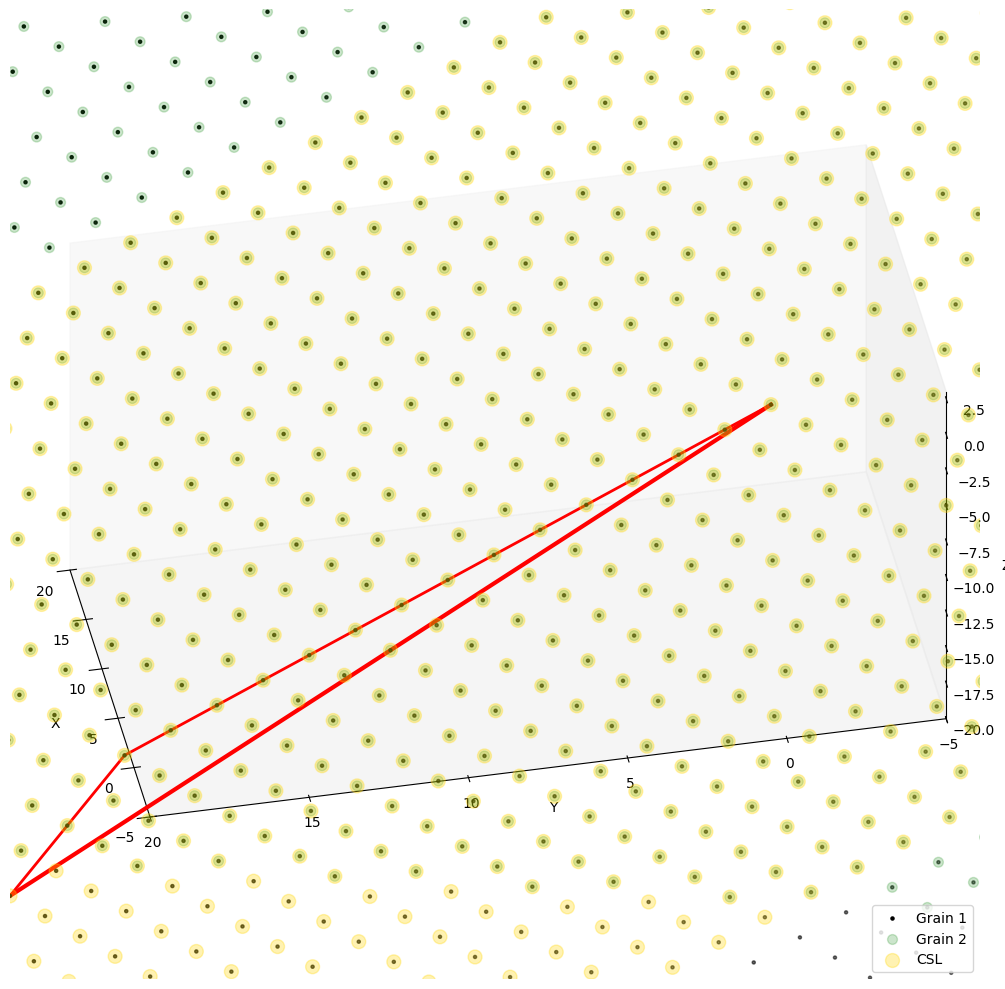

In [8]:
# Use a tilt boundary for visualisation
v1_tilt = np.array([-5, 4, 1])
O1_t, O2_t, num_t = csl.Find_Orthogonal_cell(basis, axis, m, n, v1_tilt)

ax = plot_dichromatic_pattern(v1_tilt, R, basis, M1, sigma, lim=27)

# Show the facet decomposition
plot_line(ax, dot(R, [7, 16, -29]), color='red', lw=3)
plot_line(ax, dot(R, [1, 2, -3]), length=7, color='red', lw=2)
plot_line(ax, dot(R, [0, 1, -4]),
          origin=dot(R, 7 * np.array([1, 2, -3])), length=2, color='red', lw=2)

ax.set_xlim(-5, 20)
ax.set_ylim(-5, 20)
ax.set_zlim(-20, 3)

plt.tight_layout()
plt.show()